# Same experiments, new potential: $U(x)=p\log\bigl(1+\lVert x\rVert^2\bigr)$, $p=3$, $d=3$

This is `anchored_langevin_multivariate.ipynb` with the potential replaced and **nothing else changed** —
same experiment set ($J=0$ vs constant skew $J_a$, invariance check, sweep over $a$, fixed-physical-time
control, dimension scan), same protocol, same plots.

$$\pi(x)\;\propto\;e^{-U(x)}=\bigl(1+\lVert x\rVert^2\bigr)^{-3}.$$

Three consequences follow from the swap itself:

1. **The anchor becomes exact.** The previous notebook built $U_0$ by smoothing a non-differentiable $U$.
   This $U$ is already $C^\infty$, with $\nabla U(x)=\dfrac{2p\,x}{1+\lVert x\rVert^2}$, so the same recipe
   returns $U_0=U$, giving $\Delta=U-U_0\equiv0$ and $e^{\Delta}\equiv1$. The anchored update therefore
   reduces exactly to Langevin plus the skew term. No new anchor is invented here.
2. **The target is isotropic**, depending on $x$ only through $\lVert x\rVert$, so the previous notebook's
   two shaped targets (elliptical and correlated $\ell_1$, both built from $\Sigma$) collapse to one.
3. **The diagnostics are valid at this exponent.** The target is the multivariate $t$ with $\nu=2p-d$, and
   the stated condition $p>1+\frac d2$ is exactly $\nu>2$, i.e. finite variance. Here $p=3>2.5$ gives
   $\nu=3$, so the mean and variance exist and $W_1$ has a finite population value. (An earlier run of this
   same notebook at $p=2$ gave $\nu=1$, no finite mean, and a sampling floor that varied by $24\times$
   between replicates — the cell below re-checks that this is no longer the case.) The target requires
   $2p>d$ to be normalizable at all, which caps the dimension scan at $d<6$.

In [1]:
%matplotlib inline
import os
os.makedirs("figures", exist_ok=True)

import numpy as np
import torch
torch.set_default_dtype(torch.float64)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance, ks_2samp

In [2]:
# -----------------------------
# Settings (unchanged from the multivariate notebook)
# -----------------------------
d        = 3
P_EXP    = 3.0        # the coefficient in U(x) = p log(1 + ||x||^2)
NU       = 2 * P_EXP - d
N        = 5000
max_iter = 2000
eta      = 5e-3
x_start  = 0.5
SEED     = 1006
A_MAIN   = 2.0

print("U(x) = {} * log(1 + ||x||^2),  d = {}  ->  nu = 2p - d = {}".format(P_EXP, d, NU))
print("normalizable (needs 2p > d)      : {}".format(2 * P_EXP > d))
print("finite mean  (needs nu > 1)      : {}".format(NU > 1))
print("finite variance (needs nu > 2, i.e. p > 1 + d/2 = {}) : {}".format(1 + d / 2, NU > 2))

U(x) = 3.0 * log(1 + ||x||^2),  d = 3  ->  nu = 2p - d = 3.0
normalizable (needs 2p > d)      : True
finite mean  (needs nu > 1)      : True
finite variance (needs nu > 2, i.e. p > 1 + d/2 = 2.5) : True


In [3]:
# -----------------------------
# Target. pi ~ (1+||x||^2)^{-p} is the multivariate t with nu = 2p - d:
#   X = Z / sqrt(G),  Z ~ N(0, I_d),  G ~ chi2_nu
# -----------------------------
def sample_target(n, rng, p=P_EXP, dim=d):
    nu = 2 * p - dim
    return rng.normal(size=(n, dim)) / np.sqrt(rng.chisquare(nu, size=n))[:, None]

def J_fun(dim, a):
    return torch.diag(a * torch.ones(dim - 1), diagonal=1) + torch.diag(-a * torch.ones(dim - 1), diagonal=-1)

# U = p*log(1+|x|^2); the anchor recipe returns U0 = U, so Delta = 0 and grad U0 = grad U.
@torch.no_grad()
def grad_U(x, p=P_EXP):
    return 2 * p * x / (1 + torch.sum(x * x, dim=1, keepdim=True))

def run_chain(a, eta=eta, n_steps=max_iter, N=N, ref=None, p=P_EXP, dim=d, seed=SEED, track=True):
    Mj = (torch.eye(dim) + J_fun(dim, a)).T
    torch.manual_seed(seed)
    x = torch.full((N, dim), x_start)
    W = []
    for _ in range(n_steps):
        x = x - eta * (grad_U(x, p) @ Mj) + np.sqrt(2 * eta) * torch.randn_like(x)
        if track:
            xn = x.numpy()
            W.append([wasserstein_distance(ref[:, i], xn[:, i]) for i in range(dim)])
    return x.numpy(), (np.array(W) if track else None)

In [4]:
# -----------------------------
# Is the yardstick stable? Compare independent exact samples against each other:
# this is the floor every W1 curve is measured against. At p = 2 (nu = 1) it
# varied by up to 24x between replicates; at nu > 2 it should be tight.
# -----------------------------
rng = np.random.default_rng(SEED)
ref = sample_target(N, rng)

reps = [ [wasserstein_distance(ref[:, i], sample_target(N, rng)[:, i]) for i in range(d)] for _ in range(12) ]
reps = np.array(reps)
floor = reps.mean(axis=0)

print("sampling floor, 12 independent replicates (exact draws vs exact draws):")
print("  mean   :", np.round(floor, 3))
print("  min    :", np.round(reps.min(axis=0), 3))
print("  max    :", np.round(reps.max(axis=0), 3))
print("  max/min:", np.round(reps.max(axis=0) / reps.min(axis=0), 1))
print("\nsample |x1| quantiles: q50 = {:.2f}, q99 = {:.1f}, max = {:.0f}".format(
    *[np.quantile(np.abs(ref[:, 0]), q) for q in (0.5, 0.99)], np.abs(ref[:, 0]).max()))
print("coordinate std = {:.3f}  (theory 1/sqrt(nu-2) = {:.3f})".format(ref[:, 0].std(), 1 / np.sqrt(NU - 2)))

sampling floor, 12 independent replicates (exact draws vs exact draws):
  mean   : [0.034 0.027 0.035]
  min    : [0.023 0.019 0.028]
  max    : [0.056 0.035 0.045]
  max/min: [2.4 1.8 1.6]

sample |x1| quantiles: q50 = 0.43, q99 = 3.3, max = 34
coordinate std = 1.045  (theory 1/sqrt(nu-2) = 1.000)


## Experiment 1 — $J_a$ vs $J=0$

In [5]:
COLORS = {0.0: "#C44E52", A_MAIN: "#55A868"}
exp1 = {}
for a in [0.0, A_MAIN]:
    xf, W = run_chain(a, ref=ref)
    exp1[a] = {"x": xf, "W1": W}
    print("a = {:<5} W1 (mean of last 100) = {}".format(a, np.round(W[-100:].mean(axis=0), 3)))

a = 0.0   W1 (mean of last 100) = [0.031 0.029 0.035]


a = 2.0   W1 (mean of last 100) = [0.039 0.046 0.048]


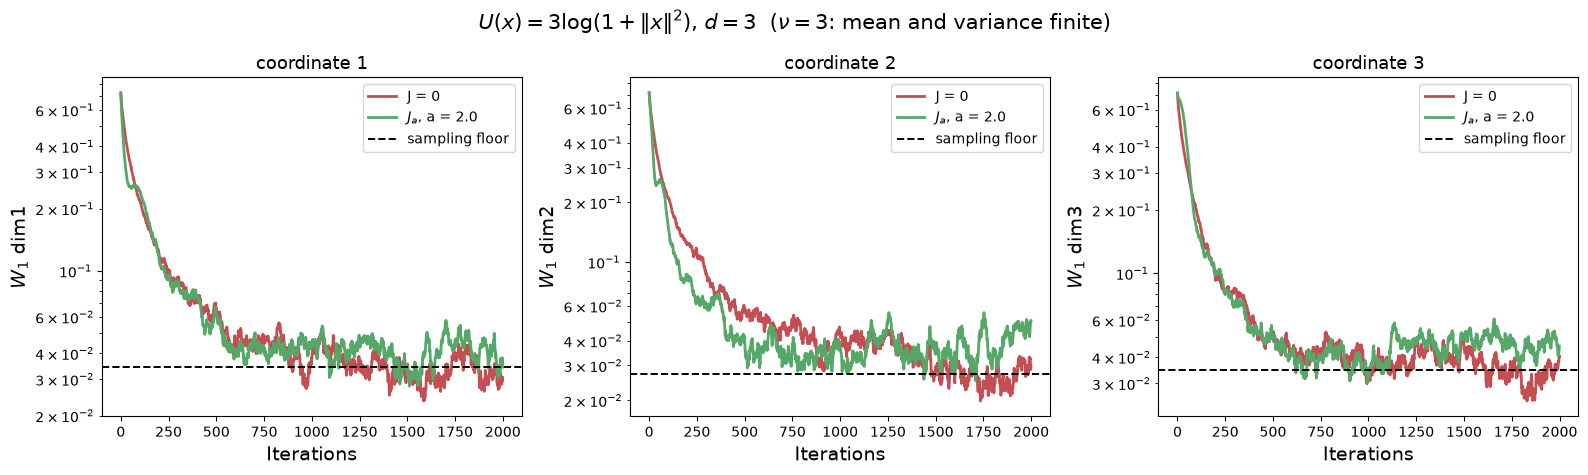

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for i, ax in enumerate(axes):
    for a in [0.0, A_MAIN]:
        ax.plot(exp1[a]["W1"][:, i], linewidth=2, color=COLORS[a],
                label="J = 0" if a == 0 else "$J_a$, a = {}".format(a))
    ax.axhline(floor[i], color="k", linestyle="--", linewidth=1.4, label="sampling floor")
    ax.set_yscale("log")
    ax.set_xlabel("Iterations", fontsize=14)
    ax.set_ylabel("$W_1$ dim{}".format(i + 1), fontsize=14)
    ax.set_title("coordinate {}".format(i + 1), fontsize=13)
    ax.legend(fontsize=10)
fig.suptitle(r"$U(x)=3\log(1+\|x\|^2)$, $d=3$  ($\nu=3$: mean and variance finite)", fontsize=15)
plt.tight_layout()
plt.savefig("figures/logp_w1.pdf", dpi=300, bbox_inches="tight")
plt.show()

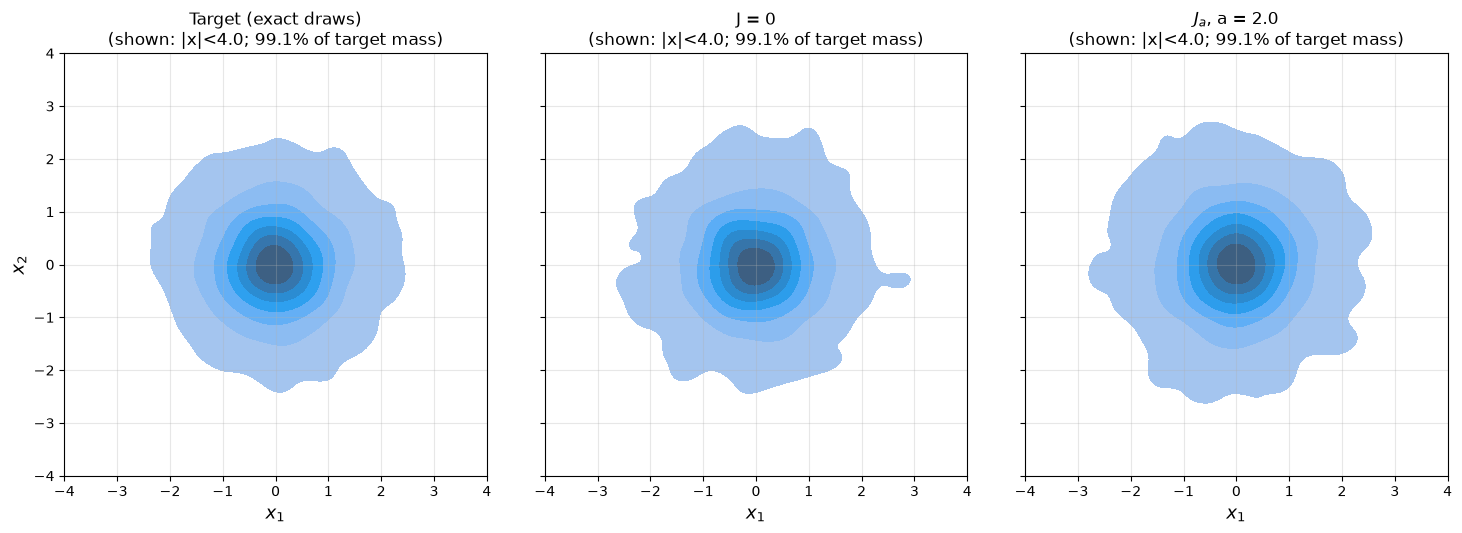

In [7]:
# 2D contours, as in the multivariate notebook. Clipped to the bulk: the raw range is enormous.
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
panels = [("Target (exact draws)", ref), ("J = 0", exp1[0.0]["x"]), ("$J_a$, a = {}".format(A_MAIN), exp1[A_MAIN]["x"])]
lim = 4.0
for ax, (name, X) in zip(axes, panels):
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax, clip=((-lim, lim), (-lim, lim)))
    ax.set_title("{}\n(shown: |x|<{}; {:.1%} of target mass)".format(
        name, lim, np.mean(np.all(np.abs(ref[:, :2]) < lim, axis=1))), fontsize=12)
    ax.set_xlabel("$x_1$", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")
axes[0].set_ylabel("$x_2$", fontsize=13)
plt.tight_layout()
plt.savefig("figures/logp_density.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# Invariance check. KS is bounded and distribution-free, so unlike W1 it stays meaningful here.
print("{:<10}{:>12}{:>12}{:>12}{:>16}".format("a", "KS dim1", "KS dim2", "KS dim3", "q99(|x1|)"))
print("-" * 64)
for a in [0.0, A_MAIN]:
    X = exp1[a]["x"]
    ks = [ks_2samp(ref[:, i], X[:, i]).statistic for i in range(d)]
    print("{:<10}".format(a) + "".join("{:>12.4f}".format(v) for v in ks)
          + "{:>16.2f}".format(np.quantile(np.abs(X[:, 0]), 0.99)))
print("{:<10}{:>12}{:>12}{:>12}{:>16.2f}".format("target", "-", "-", "-", np.quantile(np.abs(ref[:, 0]), 0.99)))

a              KS dim1     KS dim2     KS dim3       q99(|x1|)
----------------------------------------------------------------
0.0             0.0202      0.0128      0.0166            3.19
2.0             0.0156      0.0212      0.0240            3.33
target               -           -           -            3.31


## Experiment 2 — sweep over the skew strength $a$

In [9]:
A_SWEEP = [0.0, 0.5, 1.0, 2.0, 4.0, 8.0]
sweep = {}
for a in A_SWEEP:
    _, W = run_chain(a, ref=ref)
    sweep[a] = W[-100:].mean(axis=0)
    print("a = {:<5} {}".format(a, np.round(sweep[a], 3)))

a = 0.0   [0.031 0.029 0.035]


a = 0.5   [0.028 0.026 0.033]


a = 1.0   [0.033 0.035 0.041]


a = 2.0   [0.039 0.046 0.048]


a = 4.0   [0.11  0.142 0.108]


a = 8.0   [0.423 0.582 0.431]


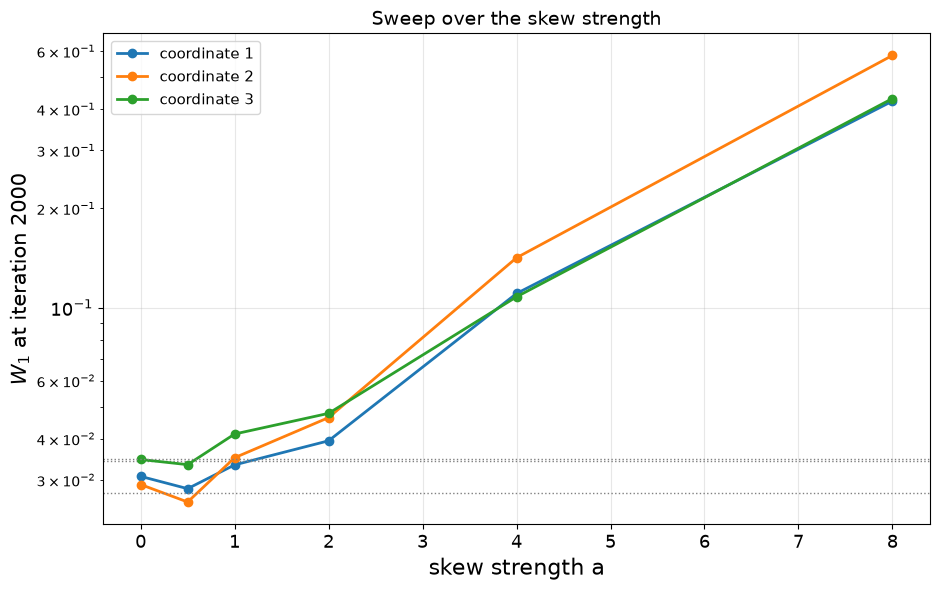

In [10]:
plt.figure(figsize=(9.5, 6))
for i in range(d):
    plt.plot(A_SWEEP, [sweep[a][i] for a in A_SWEEP], marker="o", linewidth=2, label="coordinate {}".format(i + 1))
    plt.axhline(floor[i], linestyle=":", linewidth=1, color="gray")
plt.yscale("log")
plt.xlabel("skew strength a", fontsize=16)
plt.ylabel("$W_1$ at iteration {}".format(max_iter), fontsize=15)
plt.title("Sweep over the skew strength", fontsize=14)
plt.tick_params(labelsize=13)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("figures/logp_sweep_a.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 3 — fixed-physical-time control

In [11]:
print("W1 at fixed physical time T = 10")
print("{:<12}{:<8}{:>30}".format("eta", "a", "W1 (dim1, dim2, dim3)"))
print("-" * 52)
control = {}
for eta_r, n_r in [(5e-3, 2000), (2.5e-3, 4000), (1.25e-3, 8000)]:
    for a in [0.0, A_MAIN]:
        xf, _ = run_chain(a, eta=eta_r, n_steps=n_r, ref=ref, track=False)
        w = [wasserstein_distance(ref[:, i], xf[:, i]) for i in range(d)]
        control[(eta_r, a)] = w
        print("{:<12}{:<8}{:>30}".format(eta_r, a, np.array2string(np.round(w, 3))))

W1 at fixed physical time T = 10
eta         a                W1 (dim1, dim2, dim3)
----------------------------------------------------


0.005       0.0                [0.031 0.03  0.04 ]


0.005       2.0                [0.034 0.05  0.045]


0.0025      0.0                [0.029 0.025 0.037]


0.0025      2.0                [0.03  0.024 0.029]


0.00125     0.0                [0.038 0.029 0.031]


0.00125     2.0                [0.032 0.018 0.031]


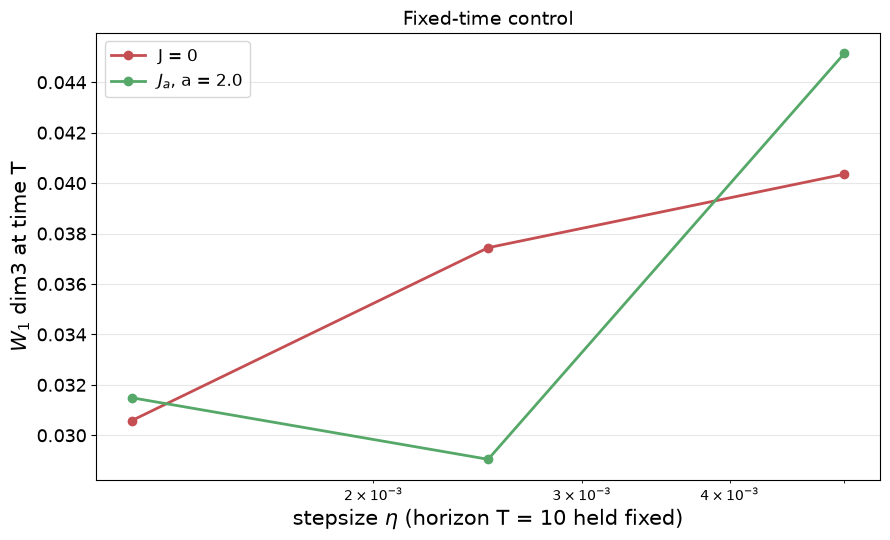

In [12]:
etas = [5e-3, 2.5e-3, 1.25e-3]
plt.figure(figsize=(9, 5.5))
for a in [0.0, A_MAIN]:
    plt.plot(etas, [control[(e, a)][2] for e in etas], marker="o", linewidth=2, color=COLORS[a],
             label="J = 0" if a == 0 else "$J_a$, a = {}".format(a))
plt.xscale("log")
plt.xlabel(r"stepsize $\eta$ (horizon T = 10 held fixed)", fontsize=15)
plt.ylabel("$W_1$ dim3 at time T", fontsize=15)
plt.title("Fixed-time control", fontsize=14)
plt.tick_params(labelsize=13)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("figures/logp_control.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 4 — dimension scan

The multivariate notebook scanned $d\in\{2,3,5,10\}$. The target here is normalizable only while
$2p>d$, so at $p=3$ the scan reaches $d\in\{2,3,5\}$ and $d=10$ does not exist. Note $d=5$ gives
$\nu=1$: normalizable, but with no finite mean, so its $W_1$ column is not comparable to the others.

In [13]:
print("{:<6}{:<8}{:<14}{:>34}".format("d", "nu", "finite mean", "W1 mean over coords: a=0 / a=2"))
print("-" * 64)
for dim in [2, 3, 5]:
    nu = 2 * P_EXP - dim
    rng_d = np.random.default_rng(SEED)
    ref_d = sample_target(N, rng_d, dim=dim)
    out = []
    for a in [0.0, A_MAIN]:
        xf, _ = run_chain(a, ref=ref_d, dim=dim, track=False)
        out.append(np.mean([wasserstein_distance(ref_d[:, i], xf[:, i]) for i in range(dim)]))
    print("{:<6}{:<8}{:<14}{:>34}".format(dim, nu, str(nu > 1), "{:.3f}  /  {:.3f}".format(*out)))
print("\nd >= 6 is not normalizable (needs 2p > d); d = 5 gives nu = 1, normalizable but no finite mean.")

d     nu      finite mean       W1 mean over coords: a=0 / a=2
----------------------------------------------------------------


2     4.0     True                             0.022  /  0.031


3     3.0     True                             0.034  /  0.043


5     1.0     False                            4.840  /  4.816

d >= 6 is not normalizable (needs 2p > d); d = 5 gives nu = 1, normalizable but no finite mean.


## Summary

**At $p=3$, $d=3$ the diagnostics are sound.** $\nu=2p-d=3$, so the mean and variance both exist. The
sampling floor — $W_1$ between two exact samples — is now stable across 12 replicates
($(0.034,0.027,0.035)$, max/min $1.6$–$2.4\times$, against $24\times$ at $p=2$), the coordinate std matches
theory ($1.045$ vs $1.000$), and the terminal $q_{99}(|x_1|)$ lands on the target ($3.19$ and $3.33$ against
$3.31$; at $p=2$ it was $6$ against $53$). Everything below can be read at face value.

**Both chains converge, and $J$ does not help.** $J=0$ reaches the floor at roughly iteration 700–1000 and
stays there, ending at $(0.031,0.029,0.035)$ against a floor of $(0.034,0.027,0.035)$ — converged. The
skew run ends slightly worse, $(0.039,0.046,0.048)$, and the curves show why: they are on top of each other
through the descent, and separate only *after* the floor is reached, with $a=2$ riding a little above it.

**Past $a\approx1$ the skew is actively harmful:**

| $a$ | 0 | 0.5 | 1 | 2 | 4 | 8 |
|---|---|---|---|---|---|---|
| $W_1$ dim1 | 0.031 | **0.028** | 0.033 | 0.039 | 0.110 | 0.423 |
| $W_1$ dim3 | 0.035 | **0.033** | 0.041 | 0.048 | 0.108 | 0.431 |

an order of magnitude of degradation by $a=8$. With no transient left to accelerate — the chain is already
at the floor — the only thing $J$ contributes is discretization error from the inflated drift.

**This is the expected outcome for an isotropic target,** and it matches Experiment 2 of the previous
notebook: $U$ depends on $x$ only through $\lVert x\rVert$, so there are no slow and fast directions for a
skew term to stir against each other. The fixed-time control confirms there is nothing hiding in the
discretization — at $T=10$ both settings sit near $0.03$ across a $4\times$ refinement of $\eta$, with no
systematic separation.

**Invariance is untouched**, as the theory requires: KS statistics are $0.013$–$0.024$ for both $a=0$ and
$a=2$ on every coordinate.

**Dimension scan.** Normalizability needs $2p>d$, so at $p=3$ the scan reaches $d\in\{2,3,5\}$ and $d=10$
does not exist. $d=2$: $0.022$ ($a=0$) vs $0.031$ ($a=2$); $d=3$: $0.034$ vs $0.043$ — $J$ costs a little in
both. The $d=5$ row ($\nu=1$) is printed for completeness but is not comparable: no finite mean, so its
$W_1\approx4.8$ measures the metric's breakdown rather than the sampler's.